In [ ]:
# Normal Dataset
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

csv_path = "heart.csv"
data = pd.read_csv(csv_path)

target_col = data.columns[-1]

y = data[target_col].copy()
X = data.drop(columns=[target_col]).copy()

if y.dtype == "object":
    y = pd.factorize(y)[0]
else:
    y = y.astype(int)

X = pd.get_dummies(X, drop_first=True)

for col in X.columns:
    if X[col].isna().any():
        X[col] = X[col].fillna(X[col].median())

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_test = scaler.transform(X_test_df)

y_train = np.array(y_train)
y_test = np.array(y_test)

classes = np.unique(y_train)

def knn_predict_one(x, X_train, y_train, k):
    eps = 0.000000000000000001
    distances = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
    sorted_idx = np.argsort(distances)
    neighbor_idx = sorted_idx[:k]

    scores = {}
    for c in classes:
        scores[int(c)] = 0.0

    for idx in neighbor_idx:
        d = distances[idx]
        w = 1.0 / (d + eps)
        label = int(y_train[idx])
        scores[label] = scores[label] + w

    best_class = None
    best_score = None
    for c in scores:
        if best_score is None or scores[c] > best_score:
            best_score = scores[c]
            best_class = c

    return best_class

def knn_predict(X_test, X_train, y_train, k):
    preds = []
    for i in range(X_test.shape[0]):
        p = knn_predict_one(X_test[i], X_train, y_train, k)
        preds.append(p)
    return np.array(preds)

def laknn_k_for_point(x, X_train, m, alpha, k_min, k_max):
    eps = 0.000000000000000001
    distances = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
    sorted_dist = np.sort(distances)

    if m < 1:
        m = 1
    if m > len(sorted_dist):
        m = len(sorted_dist)

    dm = sorted_dist[m - 1]
    raw_k = int(alpha / (dm + eps))

    if raw_k < k_min:
        raw_k = k_min
    if raw_k > k_max:
        raw_k = k_max

    return raw_k


def laknn_predict_one(x, X_train, y_train, m, alpha, k_min, k_max):
    eps = 0.000000000000000001
    kx = laknn_k_for_point(x, X_train, m, alpha, k_min, k_max)

    distances = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
    sorted_idx = np.argsort(distances)
    neighbor_idx = sorted_idx[:kx]

    scores = {}
    for c in classes:
        scores[int(c)] = 0.0

    for idx in neighbor_idx:
        d = distances[idx]
        w = 1.0 / (d + eps)
        label = int(y_train[idx])
        scores[label] = scores[label] + w

    best_class = None
    best_score = None
    for c in scores:
        if best_score is None or scores[c] > best_score:
            best_score = scores[c]
            best_class = c

    return best_class


def laknn_predict(X_test, X_train, y_train, m, alpha, k_min, k_max):
    preds = []
    for i in range(X_test.shape[0]):
        p = laknn_predict_one(X_test[i], X_train, y_train, m, alpha, k_min, k_max)
        preds.append(p)
    return np.array(preds)

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
baseline_results = []

for k in k_values:
    y_pred = knn_predict(X_test, X_train, y_train, k)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    baseline_results.append((k, acc, f1))

print("Baseline KNN Results:")
for item in baseline_results:
    print("k =", item[0], "accuracy =", round(item[1], 4), "macro_f1 =", round(item[2], 4))

m_values = [3, 5, 7]
alpha_values = [0.5, 1.0, 2.0, 4.0, 8.0]

k_min = 1
k_max = 31

laknn_results = []
best_item = None

for m in m_values:
    for alpha in alpha_values:
        y_pred = laknn_predict(X_test, X_train, y_train, m, alpha, k_min, k_max)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="macro")
        laknn_results.append((m, alpha, acc, f1))

        if best_item is None or f1 > best_item[3]:
            best_item = (m, alpha, acc, f1)

print("\nLA-KNN Results:")
for item in laknn_results:
    print("m =", item[0], "alpha =", item[1], "accuracy =", round(item[2], 4), "macro_f1 =", round(item[3], 4))

print("\nBest LA-KNN:")
print("m =", best_item[0], "alpha =", best_item[1], "accuracy =", round(best_item[2], 4), "macro_f1 =", round(best_item[3], 4))

best_baseline = None
for item in baseline_results:
    if best_baseline is None or item[2] > best_baseline[2]:
        best_baseline = item

best_k = best_baseline[0]
baseline_pred = knn_predict(X_test, X_train, y_train, best_k)
baseline_cm = confusion_matrix(y_test, baseline_pred)

best_m = best_item[0]
best_alpha = best_item[1]
laknn_pred = laknn_predict(X_test, X_train, y_train, best_m, best_alpha, k_min, k_max)
laknn_cm = confusion_matrix(y_test, laknn_pred)

print("\nBest Baseline KNN:")
print("k =", best_k)
print("accuracy =", round(accuracy_score(y_test, baseline_pred), 4))
print("macro_f1 =", round(f1_score(y_test, baseline_pred, average='macro'), 4))
print("confusion_matrix:\n", baseline_cm)

print("\nBest LA-KNN:")
print("m =", best_m, "alpha =", best_alpha)
print("accuracy =", round(accuracy_score(y_test, laknn_pred), 4))
print("macro_f1 =", round(f1_score(y_test, laknn_pred, average='macro'), 4))
print("confusion_matrix:\n", laknn_cm)


sample_count = min(50, X_test.shape[0])
k_list = []
for i in range(sample_count):
    kx = laknn_k_for_point(X_test[i], X_train, best_m, best_alpha, k_min, k_max)
    k_list.append(kx)

k_list = np.array(k_list)
print("\nLA-KNN k(x) summary on first", sample_count, "test points:")
print("min =", int(k_list.min()), "max =", int(k_list.max()), "mean =", round(float(k_list.mean()), 2))

Baseline KNN Results:
k = 1 accuracy = 1.0 macro_f1 = 1.0
k = 3 accuracy = 1.0 macro_f1 = 1.0
k = 5 accuracy = 1.0 macro_f1 = 1.0
k = 7 accuracy = 1.0 macro_f1 = 1.0
k = 9 accuracy = 1.0 macro_f1 = 1.0
k = 11 accuracy = 1.0 macro_f1 = 1.0
k = 15 accuracy = 1.0 macro_f1 = 1.0
k = 21 accuracy = 1.0 macro_f1 = 1.0
k = 31 accuracy = 1.0 macro_f1 = 1.0

LA-KNN Results:
m = 3 alpha = 0.5 accuracy = 1.0 macro_f1 = 1.0
m = 3 alpha = 1.0 accuracy = 1.0 macro_f1 = 1.0
m = 3 alpha = 2.0 accuracy = 1.0 macro_f1 = 1.0
m = 3 alpha = 4.0 accuracy = 1.0 macro_f1 = 1.0
m = 3 alpha = 8.0 accuracy = 1.0 macro_f1 = 1.0
m = 5 alpha = 0.5 accuracy = 1.0 macro_f1 = 1.0
m = 5 alpha = 1.0 accuracy = 1.0 macro_f1 = 1.0
m = 5 alpha = 2.0 accuracy = 1.0 macro_f1 = 1.0
m = 5 alpha = 4.0 accuracy = 1.0 macro_f1 = 1.0
m = 5 alpha = 8.0 accuracy = 1.0 macro_f1 = 1.0
m = 7 alpha = 0.5 accuracy = 1.0 macro_f1 = 1.0
m = 7 alpha = 1.0 accuracy = 1.0 macro_f1 = 1.0
m = 7 alpha = 2.0 accuracy = 1.0 macro_f1 = 1.0
m = 7 alp

In [ ]:
# Messy Dataset Code

import pandas as pd
import numpy as np

input_csv = "heart.csv"
output_csv = "heart_disease_noisy.csv"

data = pd.read_csv(input_csv)

target_col = data.columns[-1]

feature_cols = [c for c in data.columns if c != target_col]

drop_prob = 0.1

for col in feature_cols:
    mask = np.random.rand(len(data)) < drop_prob
    median_val = data[col].median()
    data.loc[mask, col] = median_val

flip_fraction = 0.08
num_flip = int(len(data) * flip_fraction)

flip_indices = np.random.choice(data.index, size=num_flip, replace=False)

for idx in flip_indices:
    current_label = data.loc[idx, target_col]
    data.loc[idx, target_col] = 1 - int(current_label)

for col in feature_cols:
    if np.issubdtype(data[col].dtype, np.number):
        scale = np.random.uniform(0.5, 2.0)
        data[col] = data[col] * scale

data.to_csv(output_csv, index=False)

In [ ]:
# Messy Dataset
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

csv_path = "heart_disease_noisy.csv"
data = pd.read_csv(csv_path)

target_col = data.columns[-1]

y = data[target_col].copy()
X = data.drop(columns=[target_col]).copy()

if y.dtype == "object":
    y = pd.factorize(y)[0]
else:
    y = y.astype(int)

X = pd.get_dummies(X, drop_first=True)

for col in X.columns:
    if X[col].isna().any():
        X[col] = X[col].fillna(X[col].median())

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_test = scaler.transform(X_test_df)

y_train = np.array(y_train)
y_test = np.array(y_test)

classes = np.unique(y_train)

def knn_predict_one(x, X_train, y_train, k):
    eps = 0.000000000000000001
    distances = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
    sorted_idx = np.argsort(distances)
    neighbor_idx = sorted_idx[:k]

    scores = {}
    for c in classes:
        scores[int(c)] = 0.0

    for idx in neighbor_idx:
        d = distances[idx]
        w = 1.0 / (d + eps)
        label = int(y_train[idx])
        scores[label] = scores[label] + w

    best_class = None
    best_score = None
    for c in scores:
        if best_score is None or scores[c] > best_score:
            best_score = scores[c]
            best_class = c

    return best_class

def knn_predict(X_test, X_train, y_train, k):
    preds = []
    for i in range(X_test.shape[0]):
        p = knn_predict_one(X_test[i], X_train, y_train, k)
        preds.append(p)
    return np.array(preds)

def laknn_k_for_point(x, X_train, m, alpha, k_min, k_max):
    eps = 0.000000000000000001
    distances = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
    sorted_dist = np.sort(distances)

    if m < 1:
        m = 1
    if m > len(sorted_dist):
        m = len(sorted_dist)

    dm = sorted_dist[m - 1]
    raw_k = int(alpha / (dm + eps))

    if raw_k < k_min:
        raw_k = k_min
    if raw_k > k_max:
        raw_k = k_max

    return raw_k


def laknn_predict_one(x, X_train, y_train, m, alpha, k_min, k_max):
    eps = 0.000000000000000001
    kx = laknn_k_for_point(x, X_train, m, alpha, k_min, k_max)

    distances = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
    sorted_idx = np.argsort(distances)
    neighbor_idx = sorted_idx[:kx]

    scores = {}
    for c in classes:
        scores[int(c)] = 0.0

    for idx in neighbor_idx:
        d = distances[idx]
        w = 1.0 / (d + eps)
        label = int(y_train[idx])
        scores[label] = scores[label] + w

    best_class = None
    best_score = None
    for c in scores:
        if best_score is None or scores[c] > best_score:
            best_score = scores[c]
            best_class = c

    return best_class


def laknn_predict(X_test, X_train, y_train, m, alpha, k_min, k_max):
    preds = []
    for i in range(X_test.shape[0]):
        p = laknn_predict_one(X_test[i], X_train, y_train, m, alpha, k_min, k_max)
        preds.append(p)
    return np.array(preds)

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
baseline_results = []

for k in k_values:
    y_pred = knn_predict(X_test, X_train, y_train, k)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    baseline_results.append((k, acc, f1))

print("Baseline KNN Results:")
for item in baseline_results:
    print("k =", item[0], "accuracy =", round(item[1], 4), "macro_f1 =", round(item[2], 4))

m_values = [3, 5, 7]
alpha_values = [0.5, 1.0, 2.0, 4.0, 8.0]

k_min = 1
k_max = 31

laknn_results = []
best_item = None

for m in m_values:
    for alpha in alpha_values:
        y_pred = laknn_predict(X_test, X_train, y_train, m, alpha, k_min, k_max)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="macro")
        laknn_results.append((m, alpha, acc, f1))

        if best_item is None or f1 > best_item[3]:
            best_item = (m, alpha, acc, f1)

print("\nLA-KNN Results:")
for item in laknn_results:
    print("m =", item[0], "alpha =", item[1], "accuracy =", round(item[2], 4), "macro_f1 =", round(item[3], 4))

print("\nBest LA-KNN:")
print("m =", best_item[0], "alpha =", best_item[1], "accuracy =", round(best_item[2], 4), "macro_f1 =", round(best_item[3], 4))

best_baseline = None
for item in baseline_results:
    if best_baseline is None or item[2] > best_baseline[2]:
        best_baseline = item

best_k = best_baseline[0]
baseline_pred = knn_predict(X_test, X_train, y_train, best_k)
baseline_cm = confusion_matrix(y_test, baseline_pred)

best_m = best_item[0]
best_alpha = best_item[1]
laknn_pred = laknn_predict(X_test, X_train, y_train, best_m, best_alpha, k_min, k_max)
laknn_cm = confusion_matrix(y_test, laknn_pred)

print("\nBest Baseline KNN:")
print("k =", best_k)
print("accuracy =", round(accuracy_score(y_test, baseline_pred), 4))
print("macro_f1 =", round(f1_score(y_test, baseline_pred, average='macro'), 4))
print("confusion_matrix:\n", baseline_cm)

print("\nBest LA-KNN:")
print("m =", best_m, "alpha =", best_alpha)
print("accuracy =", round(accuracy_score(y_test, laknn_pred), 4))
print("macro_f1 =", round(f1_score(y_test, laknn_pred, average='macro'), 4))
print("confusion_matrix:\n", laknn_cm)


sample_count = min(50, X_test.shape[0])
k_list = []
for i in range(sample_count):
    kx = laknn_k_for_point(X_test[i], X_train, best_m, best_alpha, k_min, k_max)
    k_list.append(kx)

k_list = np.array(k_list)
print("\nLA-KNN k(x) summary on first", sample_count, "test points:")
print("min =", int(k_list.min()), "max =", int(k_list.max()), "mean =", round(float(k_list.mean()), 2))

Baseline KNN Results:
k = 1 accuracy = 0.8439 macro_f1 = 0.8439
k = 3 accuracy = 0.8585 macro_f1 = 0.8585
k = 5 accuracy = 0.8634 macro_f1 = 0.8634
k = 7 accuracy = 0.8683 macro_f1 = 0.8683
k = 9 accuracy = 0.878 macro_f1 = 0.878
k = 11 accuracy = 0.8683 macro_f1 = 0.8682
k = 15 accuracy = 0.878 macro_f1 = 0.878
k = 21 accuracy = 0.8634 macro_f1 = 0.8634
k = 31 accuracy = 0.8634 macro_f1 = 0.8634

LA-KNN Results:
m = 3 alpha = 0.5 accuracy = 0.8439 macro_f1 = 0.8439
m = 3 alpha = 1.0 accuracy = 0.8439 macro_f1 = 0.8439
m = 3 alpha = 2.0 accuracy = 0.8439 macro_f1 = 0.8439
m = 3 alpha = 4.0 accuracy = 0.8585 macro_f1 = 0.8585
m = 3 alpha = 8.0 accuracy = 0.878 macro_f1 = 0.878
m = 5 alpha = 0.5 accuracy = 0.8439 macro_f1 = 0.8439
m = 5 alpha = 1.0 accuracy = 0.8439 macro_f1 = 0.8439
m = 5 alpha = 2.0 accuracy = 0.8439 macro_f1 = 0.8439
m = 5 alpha = 4.0 accuracy = 0.8488 macro_f1 = 0.8488
m = 5 alpha = 8.0 accuracy = 0.8829 macro_f1 = 0.8829
m = 7 alpha = 0.5 accuracy = 0.8439 macro_f1 

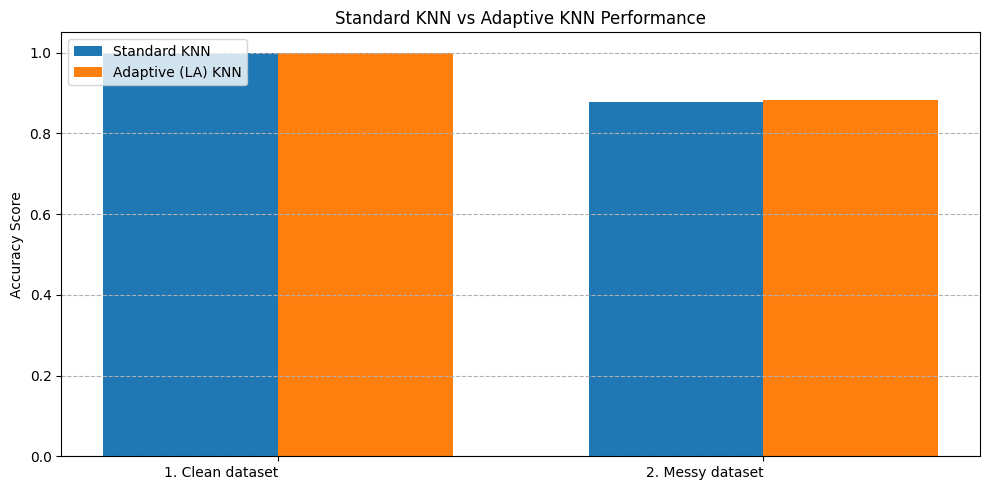

In [11]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["1. Clean dataset", "2. Messy dataset"]
standard_knn = [1.0, 0.878]
la_knn = [1.0, 0.8829]

x = np.arange(len(labels))
width = 0.36

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, standard_knn, width, label="Standard KNN")
plt.bar(x + width/2, la_knn, width, label="Adaptive (LA) KNN")

plt.title("Standard KNN vs Adaptive KNN Performance")
plt.ylabel("Accuracy Score")
plt.xticks(x, labels, ha="right")
plt.ylim(0, 1.05)

plt.grid(axis="y", linestyle="--")
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()